In [79]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [80]:
import os

print(os.getcwd())

c:\Users\Exam\Desktop\Customer Churn prediction with Deployment\notebooks


In [81]:
df = pd.read_csv("../dataset/Customer-Churn-Records.csv")

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [83]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [84]:
df.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [85]:
df.drop_duplicates(inplace=True)

In [86]:
df.dropna(inplace=True)

In [87]:
print("Rows",df.shape[0])

Rows 10000


In [88]:
print("Columns",df.shape[1])

Columns 18


In [89]:
df.columns.tolist()

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited',
 'Complain',
 'Satisfaction Score',
 'Card Type',
 'Point Earned']

In [90]:
df.describe(include='object')

,Surname,Geography,Gender,Card Type
count,10000,10000,10000,10000
unique,2932,3,2,4
top,Smith,France,Male,DIAMOND
freq,32,5014,5457,2507


In [91]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Series([], dtype: int64)

In [92]:
missing_percent = df.isnull().mean()*100

missing_percent[missing_percent>0].sort_values(ascending=False)

Series([], dtype: float64)

In [93]:
import matplotlib.pyplot as plt

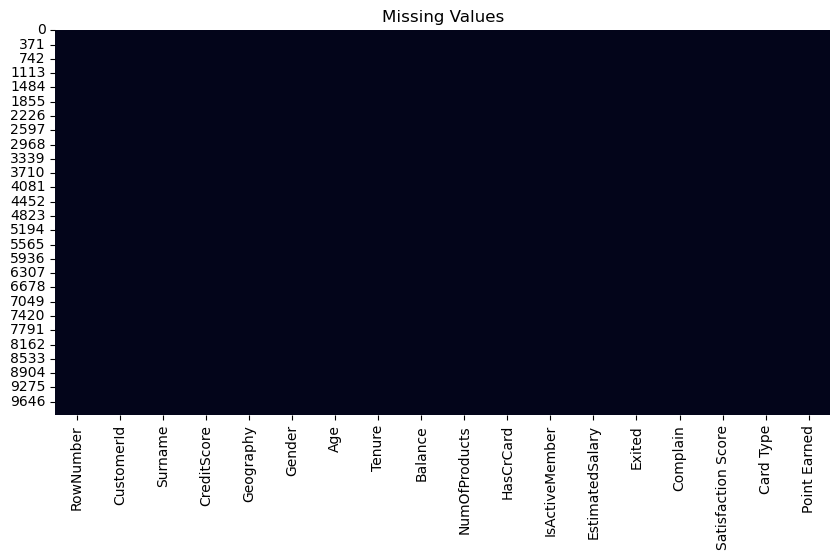

In [94]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),cbar=False)

plt.title("Missing Values")
plt.show()

In [95]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [96]:
df.dtypes

RowNumber               int64
CustomerId              int64
Surname                object
CreditScore             int64
Geography              object
Gender                 object
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64
dtype: object

In [97]:
numerical = df.select_dtypes(include=np.number)

categorical = df.select_dtypes(exclude=np.number)

print(numerical.columns)
print(categorical.columns)

Index(['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction Score', 'Point Earned'],
      dtype='object')
Index(['Surname', 'Geography', 'Gender', 'Card Type'], dtype='object')


In [98]:
import seaborn as sns


In [99]:
print(df.columns.tolist())

['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned']


In [100]:
print(df.columns)


Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')


C:\Users\Exam\AppData\Local\Temp\ipykernel_15880\2663162626.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='pastel')


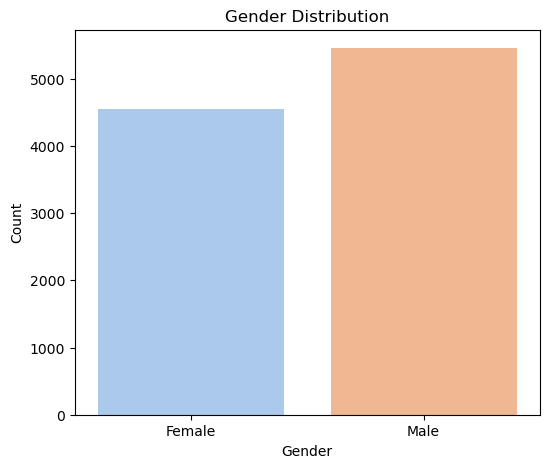

In [101]:
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

C:\Users\Exam\AppData\Local\Temp\ipykernel_15880\1061117332.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Geography', data=df, palette='viridis')


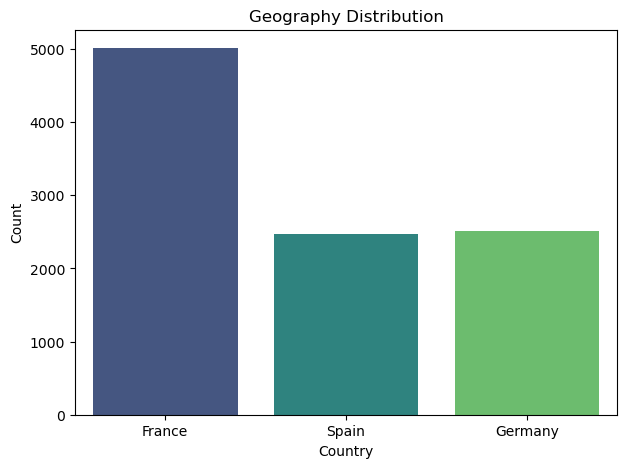

In [102]:
plt.figure(figsize=(7,5))
sns.countplot(x='Geography', data=df, palette='viridis')
plt.title("Geography Distribution")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

In [103]:
df.rename(columns={
    "Exited": "Churn",
    "Satisfaction Score": "SatisfactionScore",
    "Card Type": "CardType",
    "Point Earned": "PointEarned"
}, inplace=True)

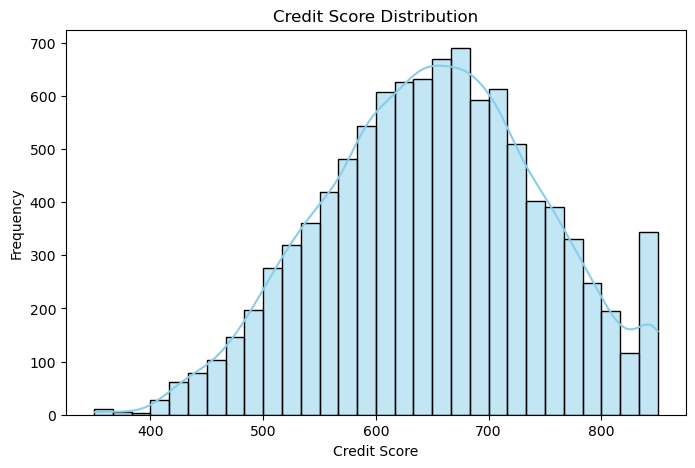

In [104]:
plt.figure(figsize=(8,5))
sns.histplot(df['CreditScore'], bins=30, kde=True, color='skyblue')
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

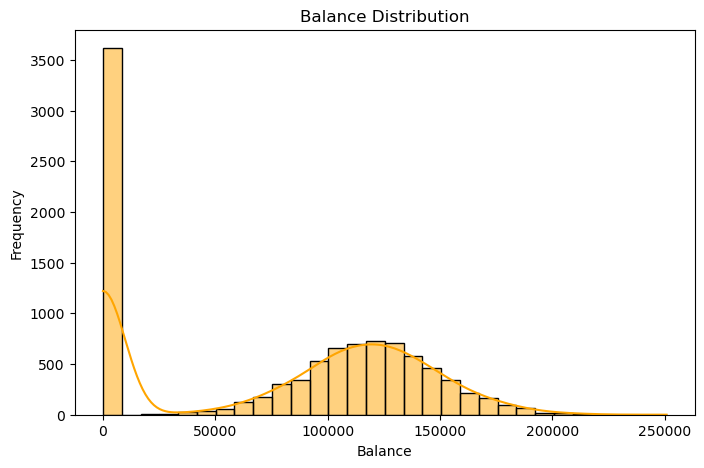

In [105]:
plt.figure(figsize=(8,5))
sns.histplot(df['Balance'], bins=30, kde=True, color='orange')
plt.title("Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

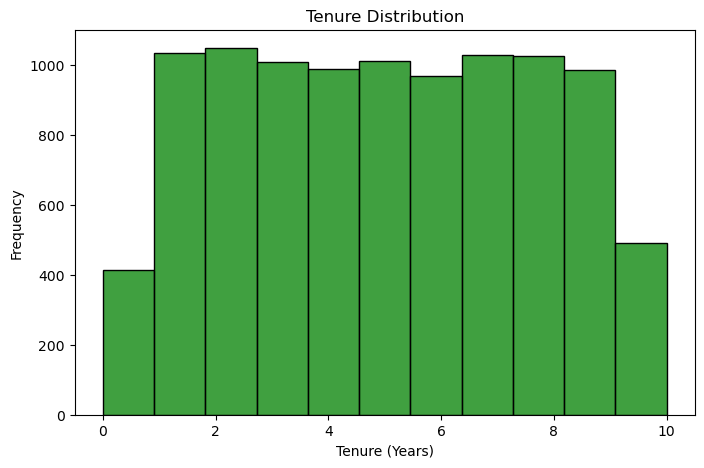

In [106]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure'], bins=11, kde=False, color='green')
plt.title("Tenure Distribution")
plt.xlabel("Tenure (Years)")
plt.ylabel("Frequency")
plt.show()

C:\Users\Exam\AppData\Local\Temp\ipykernel_15880\3374135157.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CardType', data=df, palette='coolwarm')


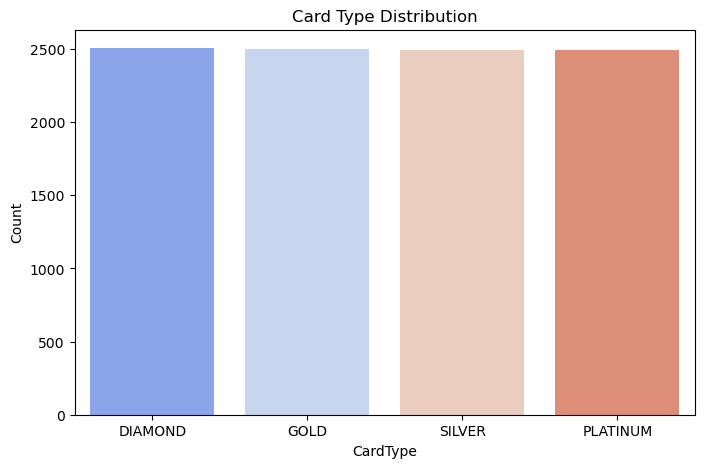

In [107]:
plt.figure(figsize=(8,5))
sns.countplot(x='CardType', data=df, palette='coolwarm')
plt.title("Card Type Distribution")
plt.xlabel("CardType")
plt.ylabel("Count")
plt.show()


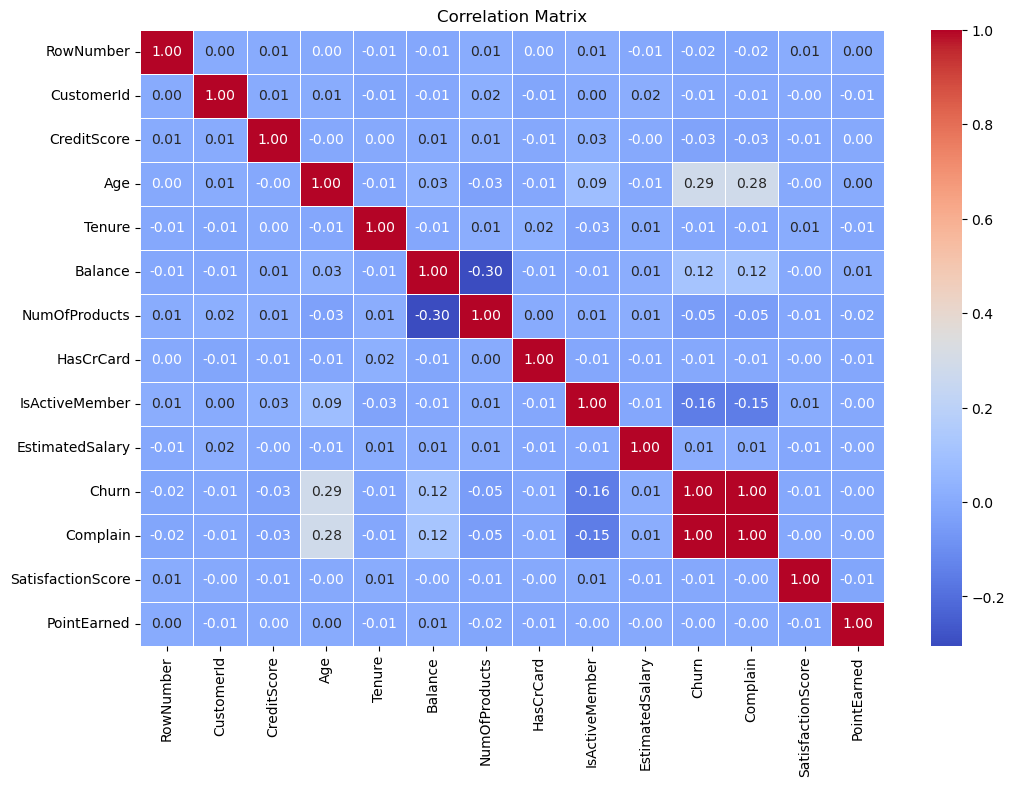

In [108]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [110]:
# Drop unnecessary columns
df = df.drop(columns=['CustomerId','RowNumber','Surname'])

In [111]:
#Label Encoding for binary categorical variables

label_encoder = LabelEncoder()
df['Gender']=label_encoder.fit_transform(df['Gender'])

In [112]:
#Separate features and target variable
x=df.drop('Churn',axis=1)
y=df['Churn']

In [113]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [114]:
# Columns
categorical_columns = ['Geography', 'CardType']

In [115]:
numerical_columns = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'EstimatedSalary',
    'Complain',
    'SatisfactionScore',
    'PointEarned'
]


categorical_features = [
    'Gender',
    'Geography',
    'CardType'
]

In [116]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [117]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

In [118]:
x_train_processed = pipeline.fit_transform(x_train)
x_test_processed = pipeline.transform(x_test)


In [119]:
print("Original Training Shape :", x_train.shape)
print("Processed Training Shape:", x_train_processed.shape)

print("Original Testing Shape :", x_test.shape)
print("Processed Testing Shape:", x_test_processed.shape)

Original Training Shape : (8000, 14)
Processed Training Shape: (8000, 17)
Original Testing Shape : (2000, 14)
Processed Testing Shape: (2000, 17)


In [120]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [121]:
x_train.dtypes

CreditScore            int64
Geography             object
Gender                 int32
Age                    int64
Tenure                 int64
Balance              float64
NumOfProducts          int64
HasCrCard              int64
IsActiveMember         int64
EstimatedSalary      float64
Complain               int64
SatisfactionScore      int64
CardType              object
PointEarned            int64
dtype: object

In [122]:
df = pd.get_dummies(
    df,
    columns=["Geography", "CardType"],
    drop_first=True
)

In [123]:
bool_cols = df.select_dtypes(include="bool").columns

df[bool_cols] = df[bool_cols].astype(int)

In [124]:
x = df.drop("Churn", axis=1)
y = df["Churn"]

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [125]:
lr = LogisticRegression(max_iter=1000)

lr.fit(x_train, y_train)

c:\Users\Exam\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [126]:
lr = LogisticRegression(max_iter=1000)

lr.fit(x_train, y_train)

lr_pred = lr.predict(x_test)
lr_prob = lr.predict_proba(x_test)[:,1]


c:\Users\Exam\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [127]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)
rf_prob = rf.predict_proba(x_test)[:,1]

In [128]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(x_train, y_train)

xgb_pred = xgb.predict(x_test)
xgb_prob = xgb.predict_proba(x_test)[:,1]

In [129]:
def evaluate_model(name, y_true, pred, prob):

    print("="*40)
    print(name)

    print("Accuracy :", accuracy_score(y_true, pred))
    print("Precision:", precision_score(y_true, pred))
    print("Recall   :", recall_score(y_true, pred))
    print("F1 Score :", f1_score(y_true, pred))
    print("ROC AUC  :", roc_auc_score(y_true, prob))

    print("\nClassification Report")

    print(classification_report(y_true, pred))

In [130]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [131]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

Logistic Regression
Accuracy : 0.9985
Precision: 0.9975429975429976
Recall   : 0.9950980392156863
F1 Score : 0.996319018404908
ROC AUC  : 0.9993025790718297

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Random Forest
Accuracy : 0.9985
Precision: 0.9975429975429976
Recall   : 0.9950980392156863
F1 Score : 0.996319018404908
ROC AUC  : 0.9994549955660657

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00    

In [132]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],

    "Recall":[
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],

    "F1":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],

    "ROC AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results.sort_values(
    by="ROC AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
1,Random Forest,0.9985,0.997543,0.995098,0.996319,0.999455
0,Logistic Regression,0.9985,0.997543,0.995098,0.996319,0.999303
2,XGBoost,0.9985,0.997543,0.995098,0.996319,0.997033


In [133]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from xgboost import XGBClassifier

In [134]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [135]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1],
    'colsample_bytree': [0.8, 0.9, 1],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5]
}

In [136]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

In [137]:
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 0.9, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretu

In [138]:
print(random_search.best_params_)

{'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}


In [139]:
best_xgb = random_search.best_estimator_

In [140]:
y_pred = best_xgb.predict(x_test)
y_prob = best_xgb.predict_proba(x_test)[:,1]

In [141]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))


Accuracy : 0.9985
Precision: 0.9975429975429976
Recall   : 0.9950980392156863
F1 Score : 0.996319018404908
ROC AUC  : 0.9994011109468912


In [142]:
import joblib

joblib.dump(best_xgb, "best_xgboost_model.pkl")

['best_xgboost_model.pkl']

In [143]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [144]:
import mlflow.xgboost

# Log XGBoost model
mlflow.xgboost.log_model(
    xgb_model=best_xgb,
    name="model"
)

In [145]:
mlflow.set_experiment("Customer_Churn_Prediction")

<Experiment: artifact_location=('file:c:/Users/Exam/Desktop/Customer Churn prediction with '
 'Deployment/notebooks/mlruns/1'), creation_time=1783656778325, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783656778325, lifecycle_stage='active', name='Customer_Churn_Prediction', tags={}, trace_location=None, workspace='default'>

In [146]:
import mlflow
import xgboost
import sklearn

print("MLflow :", mlflow.__version__)
print("XGBoost:", xgboost.__version__)
print("Scikit-learn:", sklearn.__version__)

MLflow : 3.14.0
XGBoost: 3.3.0
Scikit-learn: 1.9.0


In [147]:
import mlflow
import joblib
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

mlflow.set_experiment("Customer_Churn_Prediction")

with mlflow.start_run():

    # Train model
    best_xgb.fit(x_train, y_train)

    # Predictions
    y_pred = best_xgb.predict(x_test)
    y_prob = best_xgb.predict_proba(x_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Log Parameters
    mlflow.log_params(best_xgb.get_params())

    # Log Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Save model locally
    joblib.dump(best_xgb, "best_xgboost_model.pkl")

    # Log model as an artifact
    mlflow.log_artifact("best_xgboost_model.pkl")

    print("Run Logged Successfully")

Run Logged Successfully


In [148]:
joblib.dump(best_xgb, "best_xgboost_model.pkl")

['best_xgboost_model.pkl']

In [149]:
mlflow.log_artifact("best_xgboost_model.pkl")

In [150]:
mlflow.end_run()

In [151]:
import os
print(os.getcwd())

c:\Users\Exam\Desktop\Customer Churn prediction with Deployment\notebooks


In [155]:
import joblib

preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

print(preprocessor.transformers_)

[('num', StandardScaler(), ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'SatisfactionScore', 'PointEarned']), ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['Gender', 'Geography', 'CardType'])]


In [154]:
import os

print(os.getcwd())

c:\Users\Exam\Desktop\Customer Churn prediction with Deployment\notebooks


In [156]:
import os

print(os.path.exists("../models/preprocessor.pkl"))

True


In [157]:
print(preprocessor.transformers_)

[('num', StandardScaler(), ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Complain', 'SatisfactionScore', 'PointEarned']), ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['Gender', 'Geography', 'CardType'])]
